In [32]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
import io

try:
    # Google Colab: shows a "Choose Files" button
    from google.colab import files
    uploaded = files.upload()
    filename = next(iter(uploaded))
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
except ImportError:
    # Jupyter / VS Code: shows an "Upload" button, then re-run this cell
    import ipywidgets as widgets
    from IPython.display import display

    uploader = widgets.FileUpload(accept=".csv", multiple=False)
    display(uploader)

    if uploader.value:
        content = list(uploader.value.values())[0]["content"] if isinstance(uploader.value, dict) else uploader.value[0]["content"]
        df = pd.read_csv(io.BytesIO(content))

df.head()

In [34]:
df.head()

,year,region_id,region_name,region_ons_code,link_length_km,link_length_miles,pedal_cycles,two_wheeled_motor_vehicles,cars_and_taxis,buses_and_coaches,LGVs,all_HGVs,all_motor_vehicles
0,1993,1,South West,E12000009,48752,30293,228000000.0,289900000.0,1.967430e+10,245000000.0,2.351700e+09,1.295600e+09,2.385660e+10
1,1993,2,East Midlands,E12000004,30682,19065,199700000.0,172800000.0,1.620020e+10,190100000.0,2.082200e+09,1.647100e+09,2.029240e+10
2,1993,3,Scotland,S92000003,58533,36371,147300000.0,126400000.0,1.767760e+10,334300000.0,2.231000e+09,1.339900e+09,2.170930e+10
3,1993,4,Wales,W92000004,32544,20222,81700000.0,104600000.0,1.127880e+10,156300000.0,1.452700e+09,7.352000e+08,1.372760e+10
4,1993,5,North West,E12000002,35953,22340,251400000.0,199200000.0,2.373000e+10,339800000.0,2.801800e+09,1.834400e+09,2.890520e+10


In [35]:
df.shape

(363, 13)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        363 non-null    int64  
 1   region_id                   363 non-null    int64  
 2   region_name                 363 non-null    object 
 3   region_ons_code             363 non-null    object 
 4   link_length_km              363 non-null    int64  
 5   link_length_miles           363 non-null    int64  
 6   pedal_cycles                363 non-null    float64
 7   two_wheeled_motor_vehicles  363 non-null    float64
 8   cars_and_taxis              363 non-null    float64
 9   buses_and_coaches           363 non-null    float64
 10  LGVs                        363 non-null    float64
 11  all_HGVs                    363 non-null    float64
 12  all_motor_vehicles          363 non-null    float64
dtypes: float64(7), int64(4), object(2)


In [37]:
df.isnull().sum()

,0
year,0
region_id,0
region_name,0
region_ons_code,0
link_length_km,0
link_length_miles,0
pedal_cycles,0
two_wheeled_motor_vehicles,0
cars_and_taxis,0
buses_and_coaches,0


In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df = df.drop_duplicates()

In [40]:
df = df.drop(columns=['region_ons_code'])

In [41]:
imputer = SimpleImputer(strategy='median')

numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

In [42]:
df['traffic_level'] = pd.qcut(
    df['all_motor_vehicles'],
    q=3,
    labels=['Low','Medium','High']
)

In [43]:
encoder = LabelEncoder()

df['region_name'] = encoder.fit_transform(df['region_name'])

df['traffic_level'] = encoder.fit_transform(df['traffic_level'])

In [44]:
X = df.drop(columns=['traffic_level'])

y = df['traffic_level']

In [46]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [48]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

In [49]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

In [50]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [51]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train,y_train)

gb_pred = gb.predict(X_test)

In [52]:
parameters = {

'max_depth':[5,10,20],

'n_estimators':[100,200],

'min_samples_split':[2,5]

}

grid = GridSearchCV(

RandomForestClassifier(),

parameters,

cv=5,

scoring='accuracy'

)

grid.fit(X_train,y_train)

best_rf = grid.best_estimator_

In [53]:
scores = cross_val_score(

best_rf,

X,

y,

cv=5,

scoring='accuracy'

)

print(scores)

print(scores.mean())

[1.         0.95890411 1.         1.         1.        ]
0.9917808219178081


In [54]:
def evaluate(actual,predicted):

    print("Accuracy :",accuracy_score(actual,predicted))

    print("Precision :",precision_score(actual,predicted,average='weighted'))

    print("Recall :",recall_score(actual,predicted,average='weighted'))

    print("F1 Score :",f1_score(actual,predicted,average='weighted'))

    print(classification_report(actual,predicted))

    cm = confusion_matrix(actual,predicted)

    plt.figure(figsize=(6,5))

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

Accuracy : 0.9178082191780822
Precision : 0.9206217425395509
Recall : 0.9178082191780822
F1 Score : 0.9181976451184314
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        24
           1       0.95      0.88      0.91        24
           2       0.85      0.92      0.88        25

    accuracy                           0.92        73
   macro avg       0.92      0.92      0.92        73
weighted avg       0.92      0.92      0.92        73



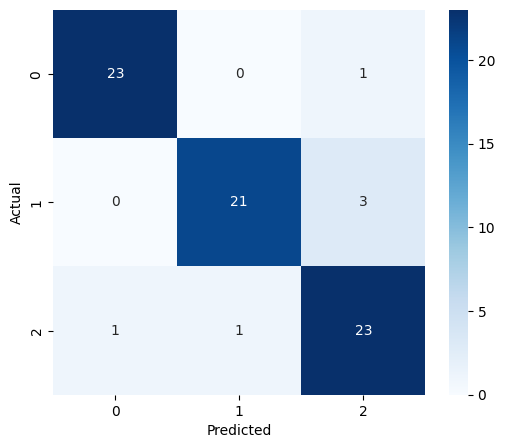

In [55]:
evaluate(y_test,lr_pred)

Accuracy : 0.9863013698630136
Precision : 0.986828240252898
Recall : 0.9863013698630136
F1 Score : 0.9862899400506341
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        24
           1       1.00      1.00      1.00        24
           2       0.96      1.00      0.98        25

    accuracy                           0.99        73
   macro avg       0.99      0.99      0.99        73
weighted avg       0.99      0.99      0.99        73



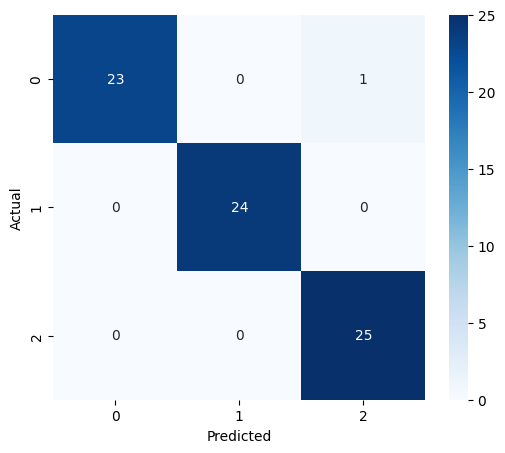

In [56]:
evaluate(y_test,dt_pred)

Accuracy : 0.9863013698630136
Precision : 0.986828240252898
Recall : 0.9863013698630136
F1 Score : 0.9862899400506341
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        24
           1       1.00      1.00      1.00        24
           2       0.96      1.00      0.98        25

    accuracy                           0.99        73
   macro avg       0.99      0.99      0.99        73
weighted avg       0.99      0.99      0.99        73



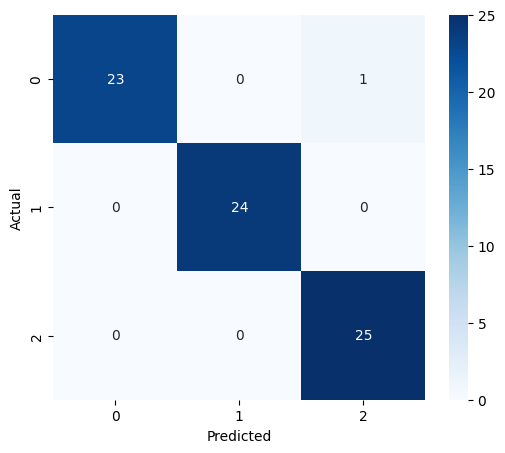

In [57]:
evaluate(y_test,rf_pred)

Accuracy : 0.9863013698630136
Precision : 0.986828240252898
Recall : 0.9863013698630136
F1 Score : 0.9862899400506341
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        24
           1       1.00      1.00      1.00        24
           2       0.96      1.00      0.98        25

    accuracy                           0.99        73
   macro avg       0.99      0.99      0.99        73
weighted avg       0.99      0.99      0.99        73



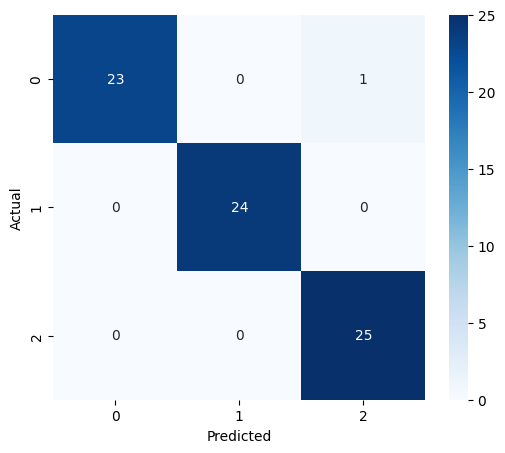

In [58]:
evaluate(y_test,gb_pred)

In [59]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test,classes=[0,1,2])

rf_prob = rf.predict_proba(X_test)

roc_auc = roc_auc_score(

y_test_bin,

rf_prob,

multi_class='ovr'

)

print("ROC-AUC =",roc_auc)

ROC-AUC = 1.0


In [60]:
importance = pd.DataFrame({

'Feature':df.drop(columns=['traffic_level']).columns,

'Importance':rf.feature_importances_

})

importance = importance.sort_values(

by='Importance',

ascending=False

)

print(importance)

                       Feature  Importance
11          all_motor_vehicles    0.334511
7               cars_and_taxis    0.261972
10                    all_HGVs    0.104177
9                         LGVs    0.093981
6   two_wheeled_motor_vehicles    0.058405
4            link_length_miles    0.055281
3               link_length_km    0.052240
5                 pedal_cycles    0.019778
2                  region_name    0.006453
1                    region_id    0.005284
8            buses_and_coaches    0.004509
0                         year    0.003408


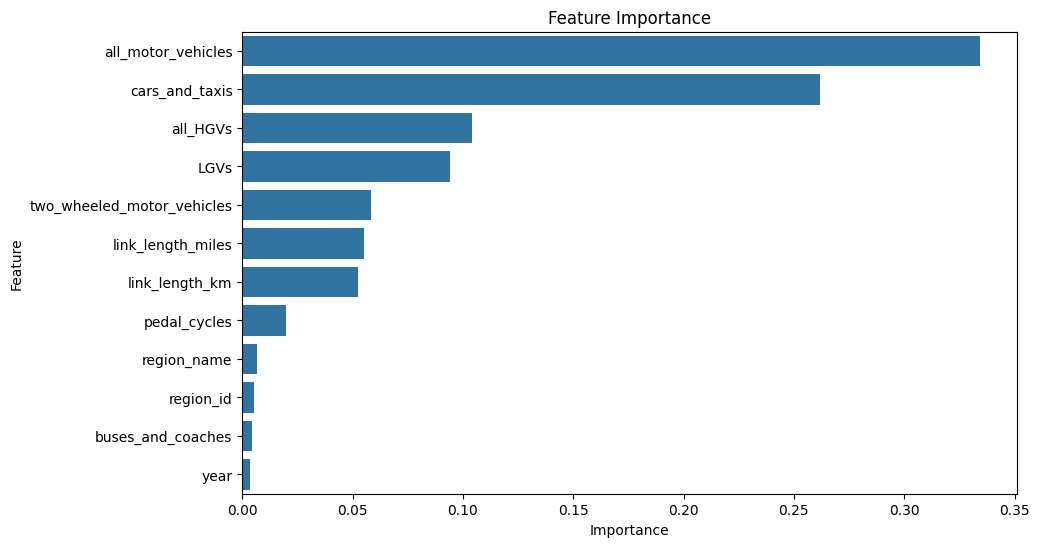

In [61]:
plt.figure(figsize=(10,6))

sns.barplot(

data=importance,

x='Importance',

y='Feature'

)

plt.title("Feature Importance")

plt.show()

In [62]:
results = pd.DataFrame({

'Model':['Logistic Regression',

'Decision Tree',

'Random Forest',

'Gradient Boosting'],

'Accuracy':[

accuracy_score(y_test,lr_pred),

accuracy_score(y_test,dt_pred),

accuracy_score(y_test,rf_pred),

accuracy_score(y_test,gb_pred)

]

})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.917808
1        Decision Tree  0.986301
2        Random Forest  0.986301
3    Gradient Boosting  0.986301


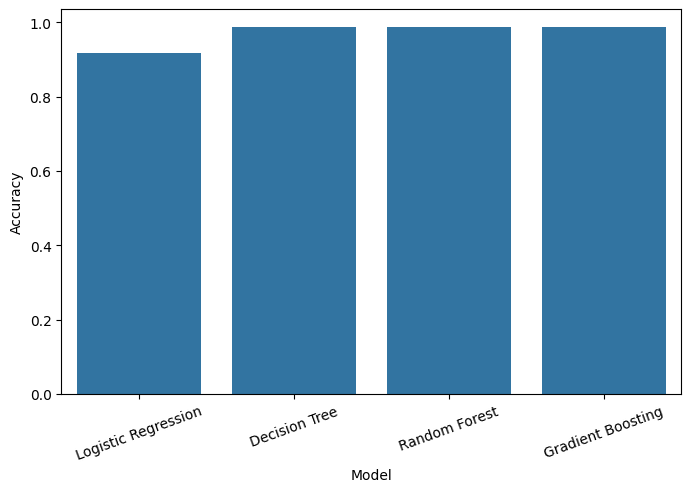

In [63]:
plt.figure(figsize=(8,5))

sns.barplot(

data=results,

x='Model',

y='Accuracy'

)

plt.xticks(rotation=20)

plt.show()